# Pipeline validation report — L1 (8 cell types), 10k-cell subsample

This is the **report** half of the L1 / 10k validation. The heavy computation lives
in a script; this notebook only loads its artifacts and renders tables + plots, so it
runs in a few seconds.

> **Run the computation first** (once, or whenever the pipeline changes):
> ```
> python scripts/validate_pipeline_l1_10k.py
> ```
> It writes the exploratory data, scores, CLR ground truth, and MLP diagnostics under
> `local_data/validation_l1_10k/`. This notebook reads only from there — it does not
> touch the raw data, train the MLP, or run the scorers.

Framing under validation: **linear** methods (Spearman, partial correlation) on the
rank-transformed matrix; **nonlinear** methods (Mutual information = Ross 2014, MLP + IG)
on the normalized + z-scored matrix.

In [ ]:
%reload_ext autoreload
%autoreload 2

In [ ]:
import json
from types import SimpleNamespace
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, confusion_matrix

from src import config, stats as st
from src.persistence import scoring_results as scoring_persistence
from src.persistence import ground_truth as gt_persistence
from src.measures.benchmarking import driver_recovery_metric
import src.plotting as P
P.set_style()

VAL_ROOT = config.LOCAL_DATA_ROOT / "validation_l1_10k"
MLP_DIR, EXP_DIR = VAL_ROOT / "mlp", VAL_ROOT / "exploratory"
meta = json.load(open(VAL_ROOT / "run_metadata.json"))
LEVEL, N_SUB = meta["level"], meta["subsample_size"]
TEST_SPLIT_SIZE, SEED = meta["test_split_size"], meta["seed"]
METHODS = meta["methods"]
meta

## 1. Exploratory analysis

Quality control, the UMAP lineage structure, the donor batch effect (before/after
Harmony), and validation of the L1 labels against the independent protein channel —
all computed on the 10k subsample by the pipeline script and loaded here.

In [ ]:
qc = pd.read_csv(EXP_DIR / "qc.csv")
fig = P.qc_violins(qc, list(qc.columns)); fig

In [ ]:
emb = np.load(EXP_DIR / "embeddings.npz", allow_pickle=True)
fig, _ = P.embedding_scatter(emb["umap"], emb["celltype"]); fig  # UMAP by cell type

In [ ]:
fig, _ = P.embedding_scatter(emb["umap"], emb["donor"]); fig  # by donor — before Harmony

In [ ]:
fig, _ = P.embedding_scatter(emb["umap_harmony"], emb["donor"]); fig  # by donor — after Harmony

In [ ]:
matz = pd.read_csv(EXP_DIR / "adt_validation.csv", index_col=0)
fig, _ = P.protein_marker_validation_heatmap(matz); fig  # mean CLR protein / cell type (z-scored)

## 2. Protein-derived ground truth (loaded)

In [ ]:
drivers = gt_persistence.load_ground_truth(
    root_dir=VAL_ROOT, level=LEVEL, subsample_size=N_SUB,
    test_split_size=TEST_SPLIT_SIZE, seed=SEED)
valid = [ct for ct, d in drivers.items() if len(d) >= config.MIN_DRIVERS]
gt_summary = (pd.DataFrame({"celltype": list(drivers),
                            "n_drivers": [len(v) for v in drivers.values()],
                            "drivers": [", ".join(sorted(v)) for v in drivers.values()]})
              .sort_values("n_drivers", ascending=False).reset_index(drop=True))
print("evaluable cell types (>= %d drivers): %s" % (config.MIN_DRIVERS, valid))
gt_summary

## 3. Per-method scores (loaded)

In [ ]:
scores = scoring_persistence.load_multiple_results(
    methods=METHODS, subsample_size=N_SUB, level=LEVEL,
    test_split_size=TEST_SPLIT_SIZE, seed=SEED, root_dir=VAL_ROOT)
for m in METHODS:
    print(f"  {config.METHOD_LABELS[m]:22s} {scores[m].shape}")

## 4. Driver-recovery benchmark ($\mathrm{AUC_{rel}}$)

Computed here from the loaded scores + ground truth (cheap).

In [22]:
rows = [{"celltype": ct, "method": m,
         "auc_rel": driver_recovery_metric.compute_auc_rel(scores[m][[ct]], {ct: drivers[ct]})}
        for m in METHODS for ct in valid]
auc = pd.DataFrame(rows)
auc_wide = auc.pivot_table(index="celltype", columns="method", values="auc_rel")[METHODS]
auc_wide.loc["— mean —"] = auc_wide.mean()
auc_wide.round(3)

method,spearman,partial_corr,mi_ksg,ig_mlp
celltype,,,,
B,0.951,0.707,0.863,0.882
CD4 T,0.968,0.930,0.878,0.923
CD8 T,0.996,0.881,0.927,0.856
DC,0.895,0.737,0.853,0.815
Mono,0.896,0.788,0.875,0.812
NK,0.934,0.759,0.801,0.790
other,0.744,0.306,0.594,0.630
other T,0.982,0.785,0.762,0.873
— mean —,0.921,0.737,0.819,0.823


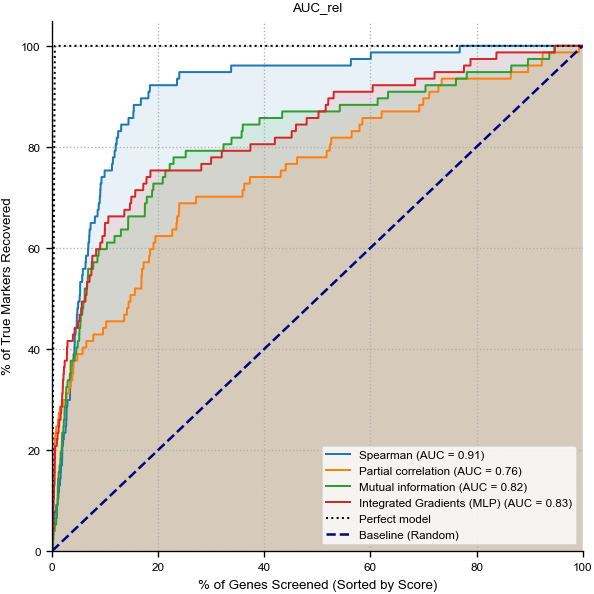

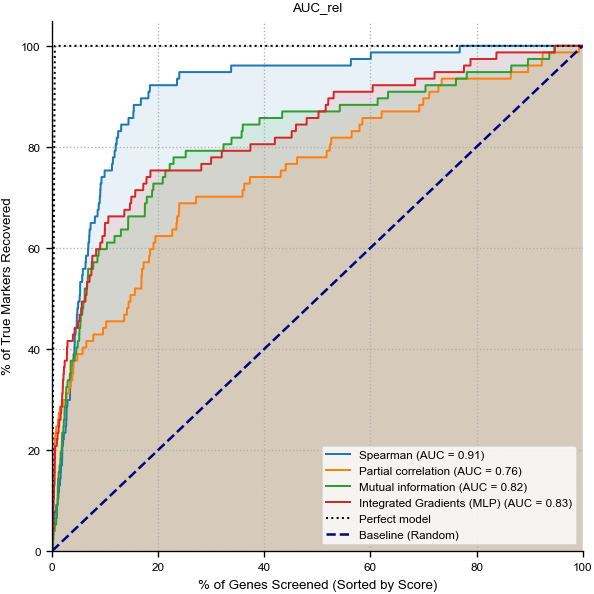

In [23]:
driver_recovery_metric.plot([scores[m].loc[:, valid] for m in METHODS],
                            [config.METHOD_LABELS[m] for m in METHODS],
                            {ct: drivers[ct] for ct in valid})
plt.gcf()

### 4.1 Per-cell-type recovery curves and early recovery

The cumulative recovery curve for **each cell type** (one panel per type; x = fraction
of ranked genes), and **recall@k** — the fraction of drivers found within the top-k
genes, averaged over cell types with a bootstrap-over-cell-types band. The whole-curve
winner and the early-recovery winner need not agree.

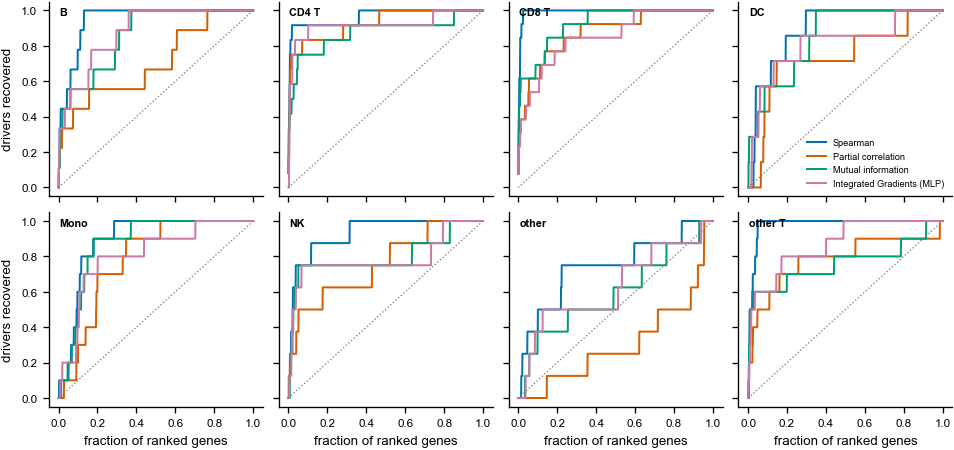

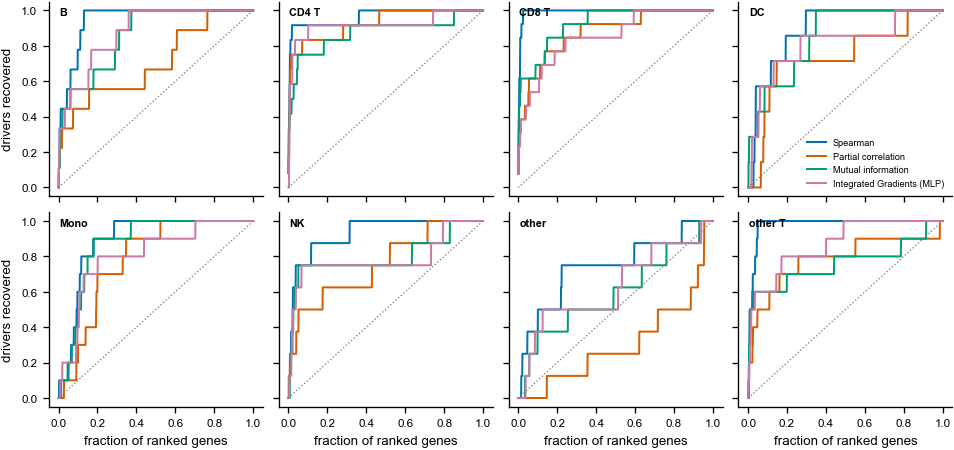

In [24]:
def recovery_curve(score_series, driver_set):
    order = score_series.sort_values(ascending=False).index
    hits = np.array([g in driver_set for g in order], dtype=float)
    n = len(order); d = max(hits.sum(), 1.0)
    return np.arange(1, n + 1) / n, np.cumsum(hits) / d

panel = {ct: {m: recovery_curve(scores[m][ct], drivers[ct]) for m in METHODS}
         for ct in valid}
fig, _ = P.recovery_curves_panel(panel, ncols=4); fig

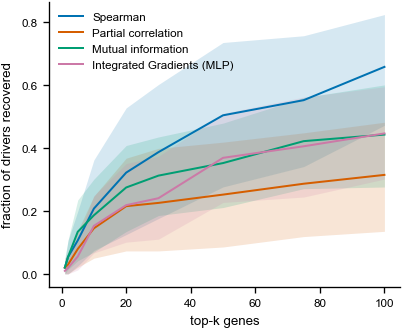

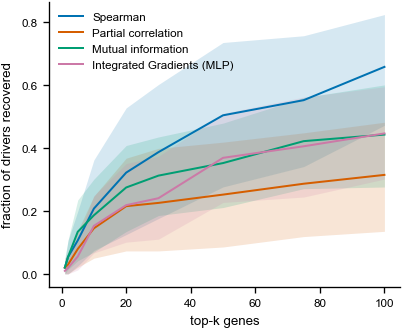

In [25]:
ks = [1, 2, 5, 10, 20, 30, 50, 75, 100]
rk = pd.DataFrame([
    {"celltype": ct, "method": m, "k": k,
     "recovery": len(set(scores[m][ct].sort_values(ascending=False).index[:k]) & drivers[ct])
                 / max(len(drivers[ct]), 1)}
    for m in METHODS for ct in valid for k in ks])
fig, _ = P.recovery_at_k_curve(rk, METHODS); fig

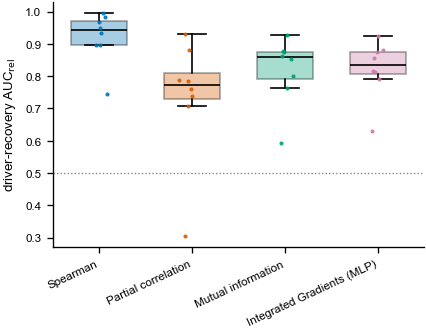

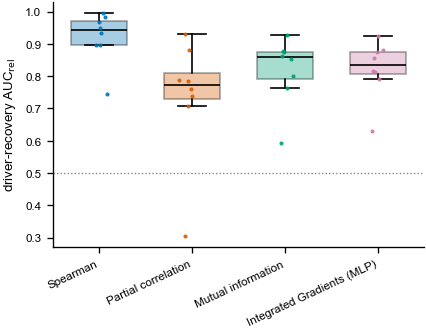

In [26]:
fig, _ = P.auc_box(auc, METHODS); fig

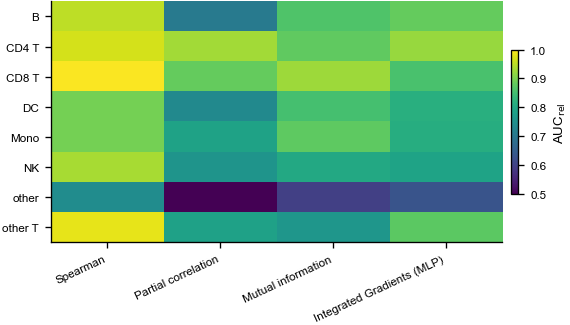

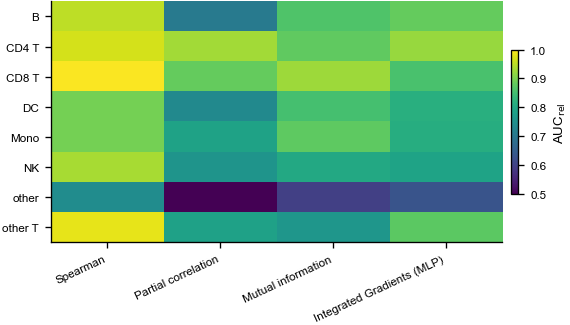

In [27]:
wide = st.pivot_auc(auc)
fig, _ = P.auc_heatmap(wide, method_order=METHODS); fig

## 5. Statistics

Friedman omnibus + Holm-corrected pairwise Wilcoxon. Only 8 L1 types, so power is
low — this is a smoke test, not the headline analysis.

In [ ]:
fried = st.friedman_test(wide)
print(f"Friedman chi2 = {fried['statistic']:.2f}, p = {fried['pvalue']:.2e} "
      f"(n = {fried['n_celltypes']} cell types)")
st.pairwise_wilcoxon(wide, method_order=METHODS)

## 6. MLP diagnostics (loaded)

In [ ]:
history = SimpleNamespace(**json.load(open(MLP_DIR / "history.json")))
print(f"best epoch {history.best_epoch} | final val-acc {history.val_acc[-1]:.3f}")
fig, _ = P.mlp_training_curves(history); fig

In [ ]:
ev = np.load(MLP_DIR / "eval.npz", allow_pickle=True)
y_true, y_pred, classes = ev["y_true"], ev["y_pred"], list(ev["classes"])
print(f"test accuracy {np.mean(y_true == y_pred):.3f} | macro-F1 "
      f"{f1_score(y_true, y_pred, average='macro'):.3f}")
f1s = pd.Series(f1_score(y_true, y_pred, average=None, labels=range(len(classes))),
                index=classes).sort_values()
fig, _ = P.per_class_bar({"MLP": f1s}); fig

In [ ]:
cm = confusion_matrix(y_true, y_pred, labels=range(len(classes)))
fig, _ = P.confusion_heatmap(cm, classes); fig

In [ ]:
um = np.load(MLP_DIR / "umap.npz", allow_pickle=True)
fig, _ = P.embedding_scatter(um["coords"], um["celltype"]); fig

## 7. Cross-method comparison (gene level)

Per-(gene, cell type) scores z-scored within cell type; protein-derived drivers
highlighted. The pairwise scatter matrix shows every method pair; the 3-D view plots
partial correlation × mutual information × Integrated Gradients together.

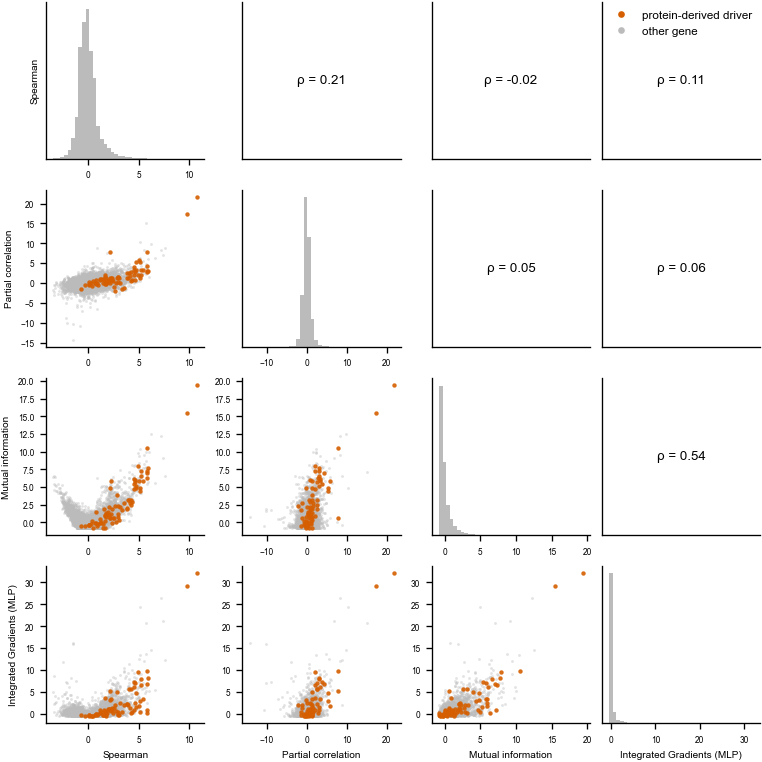

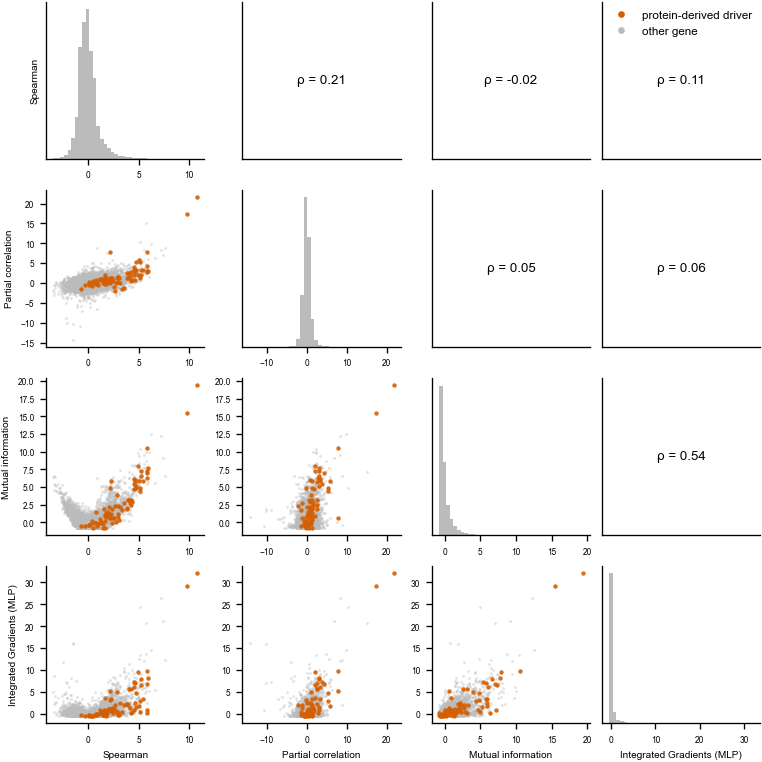

In [28]:
long = None
for m in METHODS:
    s = (scores[m].reset_index().rename(columns={scores[m].index.name or "index": "gene_name"})
         .melt(id_vars="gene_name", var_name="celltype", value_name=m))
    s = s[s.celltype.isin(valid)].set_index(["gene_name", "celltype"])
    long = s if long is None else long.join(s)
long = long.reset_index()
long["is_driver"] = [g in drivers.get(ct, set()) for g, ct in zip(long.gene_name, long.celltype)]
for m in METHODS:
    long[m] = long.groupby("celltype")[m].transform(lambda v: (v - v.mean()) / (v.std() + 1e-9))
fig, _ = P.pairwise_scatter_matrix(long, METHODS); fig

In [ ]:
fig, _ = P.scatter3d(long, config.METHOD_PARTIAL_CORRELATION,
                     config.METHOD_MI_KSG, config.METHOD_IG_MLP); fig

## 8. Summary

Loaded the persisted L1 / 10k artifacts and reproduced the full report — exploratory
analysis (QC, UMAP, donor batch, ADT label validation), the protein-derived ground
truth, the four dependency measures, the AUC_rel benchmark, statistics, MLP diagnostics
(training curves, per-class F1, confusion, penultimate-layer UMAP), and the gene-level
cross-method comparison (pairwise + 3-D scatter). Every stage of the corrected pipeline
is exercised; regenerate the artifacts with `scripts/validate_pipeline_l1_10k.py` after
any pipeline change, then re-run this notebook.